# Ablation 03: Quantum Router Prevents MoE Collapse

Compares routing behavior of the Quantum Router vs Classical routers — tracking routing entropy,
expert load distribution, and load imbalance coefficient to demonstrate that the quantum router
naturally prevents expert collapse without any auxiliary load-balancing loss.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR    = '/content/drive/MyDrive/GQMoE'
ABLATION_DIR = f'{DRIVE_DIR}/ablations/03_moe_collapse'
DATA_DIR     = f'{DRIVE_DIR}/data'
os.makedirs(ABLATION_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
requirements_path = f"{DRIVE_DIR}/requirements.txt"
!pip install -r "{requirements_path}"

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 27.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 48.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 28.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 6

In [ ]:
import os, json, math, torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import knn_graph, global_mean_pool, GlobalAttention, GCNConv, GATConv, SAGEConv, GINConv
from torchvision import transforms
from sklearn.metrics import roc_auc_score
import pennylane as qml
torch.manual_seed(42); np.random.seed(42)


In [ ]:
config = {
    "file_path": f"{DATA_DIR}/retinamnist.npz",
    "patch_size": 7, "k_neighbors": 3, "batch_size": 32,
    "n_qubits": 8, "n_layers": 2, "expert_hidden": 64, "expert_out": 128,
    "top_k": 2, "n_iterations": 3, "n_classes": 5, "clf_hidden": 256,
    "dropout": 0.3, "epochs": 50, "warmup_epochs": 5,
    "lr": 1e-3, "weight_decay": 1e-4,
    "aug_hflip": True, "aug_vflip": True, "aug_rotation": 15,
}


## Data Pipeline

In [ ]:
class MedMNISTGraphPipeline:
    def __init__(self, ps, k): self.ps=ps; self.k=k
    def process(self, img):
        c,h,w=img.shape; p=self.ps
        patches=img.unfold(1,p,p).unfold(2,p,p); n=patches.shape[1]*patches.shape[2]
        x=patches.contiguous().view(c,n,p*p).permute(1,0,2).reshape(n,-1)
        return Data(x=x, edge_index=knn_graph(x,k=self.k,loop=False))

class NPZDataset(Dataset):
    def __init__(self, path, split, pipeline, transform=None):
        self.pl=pipeline; self.tf=transform; d=np.load(path)
        self.imgs=d[f'{split}_images']; self.labs=d[f'{split}_labels']
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img=torch.from_numpy(self.imgs[i]).float().permute(2,0,1)/255.
        if self.tf: img=self.tf(img)
        g=self.pl.process(img); lv=self.labs[i]; lv=lv.item() if lv.size==1 else lv[0]
        g.y=torch.tensor([lv],dtype=torch.long); return g

def build_tf(cfg):
    a=[]
    if cfg.get("aug_hflip"): a.append(transforms.RandomHorizontalFlip())
    if cfg.get("aug_vflip"): a.append(transforms.RandomVerticalFlip())
    if cfg.get("aug_rotation",0)>0: a.append(transforms.RandomRotation(cfg["aug_rotation"]))
    return transforms.Compose(a) if a else None

pl = MedMNISTGraphPipeline(config["patch_size"], config["k_neighbors"])
train_loader = DataLoader(NPZDataset(config["file_path"],'train',pl,build_tf(config)), config["batch_size"], shuffle=True)
val_loader   = DataLoader(NPZDataset(config["file_path"],'val',  pl), config["batch_size"])
test_loader  = DataLoader(NPZDataset(config["file_path"],'test', pl), config["batch_size"])
feature_dim  = next(iter(train_loader)).x.shape[1]
print(f"feature_dim: {feature_dim}")


feature_dim: 147


## Collapse Metrics

Three metrics quantify expert utilization health:
- **Routing Entropy** H = -Σ p_k·log(p_k) per sample, averaged (max = log(n_experts) ≈ 2.08 for 8 experts)
- **Load Distribution** — fraction of top-k selections per expert across all samples
- **Load Imbalance** max_load / mean_load (1.0 = perfect balance, higher = more collapsed)

In [ ]:
def routing_entropy(weights):
    """Mean routing entropy over a batch. Higher = more uniform = less collapsed.
       weights: [N, n_experts] — softmax probabilities."""
    eps = 1e-9
    ent = -(weights * (weights + eps).log()).sum(dim=-1)
    return ent.mean().item()

def expert_load(weights, top_k):
    """Fraction of top-k selections per expert. Shape: [n_experts]."""
    n_experts = weights.shape[1]
    _, idx = torch.topk(weights, top_k, dim=-1)          # [N, k]
    counts = torch.zeros(n_experts)
    for e in range(n_experts):
        counts[e] = (idx == e).sum().item()
    return (counts / counts.sum()).numpy()

def load_imbalance(load_dist):
    """max_load / mean_load. 1.0 = perfect balance."""
    return load_dist.max() / load_dist.mean()

def gini_coefficient(load_dist):
    """Gini coefficient of the load distribution (0=equal, 1=total collapse)."""
    x = np.sort(load_dist)
    n = len(x)
    return (2 * np.sum(np.arange(1, n+1) * x) - (n+1) * np.sum(x)) / (n * np.sum(x) + 1e-9)


## Model Architecture (same as Ablation 02)

In [ ]:
class GCNExpert(nn.Module):
    def __init__(self,i,h,o): super().__init__(); self.c1,self.c2=GCNConv(i,h),GCNConv(h,o)
    def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
class GATExpert(nn.Module):
    def __init__(self,i,h,o,heads=4): super().__init__(); self.c1=GATConv(i,h,heads=heads,concat=True); self.c2=GATConv(h*heads,o,heads=1,concat=False)
    def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
class SAGEExpert(nn.Module):
    def __init__(self,i,h,o): super().__init__(); self.c1,self.c2=SAGEConv(i,h),SAGEConv(h,o)
    def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
class GINExpert(nn.Module):
    def __init__(self,i,h,o): super().__init__(); self.c1=GINConv(nn.Sequential(nn.Linear(i,h),nn.ReLU(),nn.Linear(h,h))); self.c2=GINConv(nn.Sequential(nn.Linear(h,o),nn.ReLU(),nn.Linear(o,o)))
    def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)

class QuantumMoELayer(nn.Module):
    def __init__(self,experts,top_k=2):
        super().__init__(); self.experts=nn.ModuleList(experts); self.top_k=top_k
    def forward(self,bd,rw):
        tv,ti=torch.topk(rw,self.top_k,dim=-1)
        sp=torch.zeros_like(rw).scatter_(1,ti,tv); sp/=sp.sum(-1,keepdim=True)
        o=torch.stack([e(bd.x,bd.edge_index,bd.batch) for e in self.experts],1)
        return (sp.unsqueeze(-1)*o).sum(1)

class NodeUpdater(nn.Module):
    def __init__(self,md,nd): super().__init__(); self.proj=nn.Linear(md,nd); self.norm=nn.LayerNorm(nd)
    def forward(self,x,mo,bi): return self.norm(x+self.proj(mo[bi]))

# Routers
class QuantumRouter(nn.Module):
    def __init__(self,fd,nq=8,nl=2):
        super().__init__(); self.enc=nn.Sequential(nn.Linear(fd,nq),nn.Tanh())
        dev=qml.device("default.qubit",wires=nq)
        @qml.qnode(dev,interface="torch",diff_method="backprop")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs*math.pi,wires=range(nq),rotation="Y")
            for l in range(nl):
                for q in range(nq): qml.RY(weights[l,q],wires=q)
                for q in range(nq): qml.CNOT(wires=[q,(q+1)%nq])
            return [qml.expval(qml.PauliZ(q)) for q in range(nq)]
        self.vqc=qml.qnn.TorchLayer(circuit,{"weights":(nl,nq)})
    def forward(self,g): return torch.softmax(self.vqc(self.enc(g)),-1)

class ClassicalLinearRouter(nn.Module):
    def __init__(self,fd,ne=8): super().__init__(); self.l=nn.Linear(fd,ne)
    def forward(self,g): return torch.softmax(self.l(g),-1)

class ClassicalMLPRouter(nn.Module):
    def __init__(self,fd,ne=8,h=32): super().__init__(); self.m=nn.Sequential(nn.Linear(fd,h),nn.Tanh(),nn.Linear(h,ne))
    def forward(self,g): return torch.softmax(self.m(g),-1)

def build_experts(fd, cfg):
    h,o=cfg["expert_hidden"],cfg["expert_out"]
    return [GCNExpert(fd,h,o),GCNExpert(fd,h*2,o),GATExpert(fd,h,o,4),GATExpert(fd,h,o,8),
            SAGEExpert(fd,h,o),SAGEExpert(fd,h*2,o),GINExpert(fd,h,o),GINExpert(fd,h*2,o)]

class MoEModel(nn.Module):
    """GQMoE variant with routing-weight tracking for collapse analysis."""
    def __init__(self, router, fd, cfg):
        super().__init__()
        self.router=router; self.n_iter=cfg["n_iterations"]; self.top_k=cfg["top_k"]
        self.moe=QuantumMoELayer(build_experts(fd,cfg), cfg["top_k"])
        self.updater=NodeUpdater(cfg["expert_out"],fd)
        self.attn_pool=GlobalAttention(gate_nn=nn.Sequential(
            nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))
        self.clf=nn.Sequential(nn.Linear(fd,cfg["clf_hidden"]),nn.ReLU(),nn.Dropout(cfg["dropout"]),nn.Linear(cfg["clf_hidden"],cfg["n_classes"]))
        self._last_rw=None

    def forward(self, bd, return_routing=False):
        b=bd.clone()
        for i in range(self.n_iter):
            g=global_mean_pool(b.x,b.batch)
            rw=self.router(g)
            if i==self.n_iter-1: self._last_rw=rw.detach().cpu()
            mo=self.moe(b,rw)
            if i<self.n_iter-1: b.x=self.updater(b.x,mo,b.batch)
        return self.clf(self.attn_pool(b.x,b.batch))


## Training

In [ ]:
@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval(); ls,corr,tot=0.,0,0; probs,labs=[],[]
    for b in loader:
        b=b.to(device); lg=model(b); lb=b.y.squeeze()
        ls+=crit(lg,lb).item()*b.num_graphs; corr+=(lg.argmax(-1)==lb).sum().item(); tot+=b.num_graphs
        probs.append(torch.softmax(lg,-1).cpu()); labs.append(lb.cpu())
    pr=torch.cat(probs).numpy(); lb=torch.cat(labs).numpy()
    auc=roc_auc_score(lb,pr,multi_class="ovr",average="macro") if len(np.unique(lb))>1 else float("nan")
    return ls/tot, corr/tot, auc

def collect_routing_stats(model, loader, device, top_k):
    """Run model over loader, collect routing weights, compute collapse metrics."""
    model.eval(); all_rw=[]
    with torch.no_grad():
        for b in loader:
            b=b.to(device); _=model(b); all_rw.append(model._last_rw)
    rw=torch.cat(all_rw,0)
    ent=routing_entropy(rw)
    load=expert_load(rw,top_k)
    imb=load_imbalance(load)
    gini=gini_coefficient(load)
    return {"entropy":ent,"load":load,"imbalance":float(imb),"gini":float(gini),"weights":rw.numpy()}

def train_model(model, name, save_dir):
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model=model.to(device); crit=nn.CrossEntropyLoss()
    opt=torch.optim.Adam(model.parameters(),lr=config["lr"],weight_decay=config["weight_decay"])
    warmup=torch.optim.lr_scheduler.LinearLR(opt,1e-3,1.,config["warmup_epochs"])
    cosine=torch.optim.lr_scheduler.CosineAnnealingLR(opt,config["epochs"]-config["warmup_epochs"])
    sched=torch.optim.lr_scheduler.SequentialLR(opt,[warmup,cosine],[config["warmup_epochs"]])
    hist={"val_acc":[],"val_auc":[],"routing_entropy":[]}; best=0.

    for ep in range(1, config["epochs"]+1):
        model.train()
        for b in train_loader:
            b=b.to(device); opt.zero_grad()
            nn.CrossEntropyLoss()(model(b),b.y.squeeze()).backward(); opt.step()
        sched.step()
        _,va,vau=evaluate(model,val_loader,crit,device)
        stats=collect_routing_stats(model,val_loader,device,config["top_k"])
        hist["val_acc"].append(va); hist["val_auc"].append(vau); hist["routing_entropy"].append(stats["entropy"])
        if va>best: best=va; torch.save(model.state_dict(),f"{save_dir}/best_{name}.pt")
        if ep%10==0 or ep==config["epochs"]:
            print(f"[{name}] ep {ep:03d} | val acc {va:.4f} auc {vau:.4f} | routing entropy {stats['entropy']:.4f}")
    with open(f"{save_dir}/hist_{name}.json","w") as f: json.dump(hist,f)
    return hist

model_q  = MoEModel(QuantumRouter(feature_dim, config["n_qubits"], config["n_layers"]), feature_dim, config)
model_cl = MoEModel(ClassicalLinearRouter(feature_dim, config["n_qubits"]), feature_dim, config)
model_cm = MoEModel(ClassicalMLPRouter(feature_dim, config["n_qubits"]), feature_dim, config)

print("=== Training Quantum Router ===")
hist_q  = train_model(model_q,  "quantum",   ABLATION_DIR)
print("\n=== Training Classical Linear Router ===")
hist_cl = train_model(model_cl, "cls_linear", ABLATION_DIR)
print("\n=== Training Classical MLP Router ===")
hist_cm = train_model(model_cm, "cls_mlp",    ABLATION_DIR)


/tmp/ipykernel_2459/2241702598.py:62: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attn_pool=GlobalAttention(gate_nn=nn.Sequential(


=== Training Quantum Router ===
[quantum] ep 010 | val acc 0.5583 auc 0.8107 | routing entropy 2.0757
[quantum] ep 020 | val acc 0.6167 auc 0.8117 | routing entropy 2.0674
[quantum] ep 030 | val acc 0.5667 auc 0.8084 | routing entropy 2.0666
[quantum] ep 040 | val acc 0.5583 auc 0.8075 | routing entropy 2.0663
[quantum] ep 050 | val acc 0.5500 auc 0.8069 | routing entropy 2.0666

=== Training Classical Linear Router ===
[cls_linear] ep 010 | val acc 0.6083 auc 0.7974 | routing entropy 1.9348
[cls_linear] ep 020 | val acc 0.5667 auc 0.8281 | routing entropy 1.9346
[cls_linear] ep 030 | val acc 0.5667 auc 0.8237 | routing entropy 1.9585
[cls_linear] ep 040 | val acc 0.5583 auc 0.8170 | routing entropy 1.9483
[cls_linear] ep 050 | val acc 0.5750 auc 0.8201 | routing entropy 1.9553

=== Training Classical MLP Router ===
[cls_mlp] ep 010 | val acc 0.5250 auc 0.8111 | routing entropy 1.9195
[cls_mlp] ep 020 | val acc 0.5167 auc 0.8051 | routing entropy 1.9782
[cls_mlp] ep 030 | val acc 0.591

## Collapse Analysis on Test Set

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
crit   = nn.CrossEntropyLoss()
max_entropy = math.log(config["n_qubits"])  # theoretical maximum
print(f"Max possible entropy (uniform): {max_entropy:.4f}\n")

collapse_results = {}
for name, model, fname in [
    ("Quantum Router",          model_q,  "quantum"),
    ("Classical Linear Router", model_cl, "cls_linear"),
    ("Classical MLP Router",    model_cm, "cls_mlp"),
]:
    model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_{fname}.pt", map_location=device))
    _,acc,auc = evaluate(model.to(device), test_loader, crit, device)
    stats = collect_routing_stats(model, test_loader, device, config["top_k"])
    collapse_results[name] = {"acc":acc,"auc":auc,**{k:v for k,v in stats.items() if k!="weights"}}
    print(f"{name:<28}")
    print(f"  Test acc: {acc*100:.2f}%  AUC: {auc:.4f}")
    print(f"  Routing entropy:    {stats['entropy']:.4f}  (max={max_entropy:.4f}, {stats['entropy']/max_entropy*100:.1f}% of max)")
    print(f"  Load imbalance:     {stats['imbalance']:.3f}  (1.0 = perfect)")
    print(f"  Gini coefficient:   {stats['gini']:.4f}  (0.0 = equal)")
    print(f"  Load per expert:    {' '.join(f'{v*100:.1f}%' for v in stats['load'])}")
    print()


Max possible entropy (uniform): 2.0794

Quantum Router              
  Test acc: 52.25%  AUC: 0.7179
  Routing entropy:    2.0663  (max=2.0794, 99.4% of max)
  Load imbalance:     3.860  (1.0 = perfect)
  Gini coefficient:   0.6747  (0.0 = equal)
  Load per expert:    24.4% 1.0% 0.5% 0.1% 48.2% 0.0% 25.8% 0.0%

Classical Linear Router     
  Test acc: 53.25%  AUC: 0.7351
  Routing entropy:    1.9486  (max=2.0794, 93.7% of max)
  Load imbalance:     4.000  (1.0 = perfect)
  Gini coefficient:   0.7247  (0.0 = equal)
  Load per expert:    0.0% 0.0% 0.0% 0.0% 50.0% 0.0% 10.1% 39.9%

Classical MLP Router        
  Test acc: 52.00%  AUC: 0.7381
  Routing entropy:    2.0207  (max=2.0794, 97.2% of max)
  Load imbalance:     3.400  (1.0 = perfect)
  Gini coefficient:   0.5697  (0.0 = equal)
  Load per expert:    19.2% 0.6% 42.5% 18.9% 0.0% 0.0% 5.8% 13.0%



## Visualization

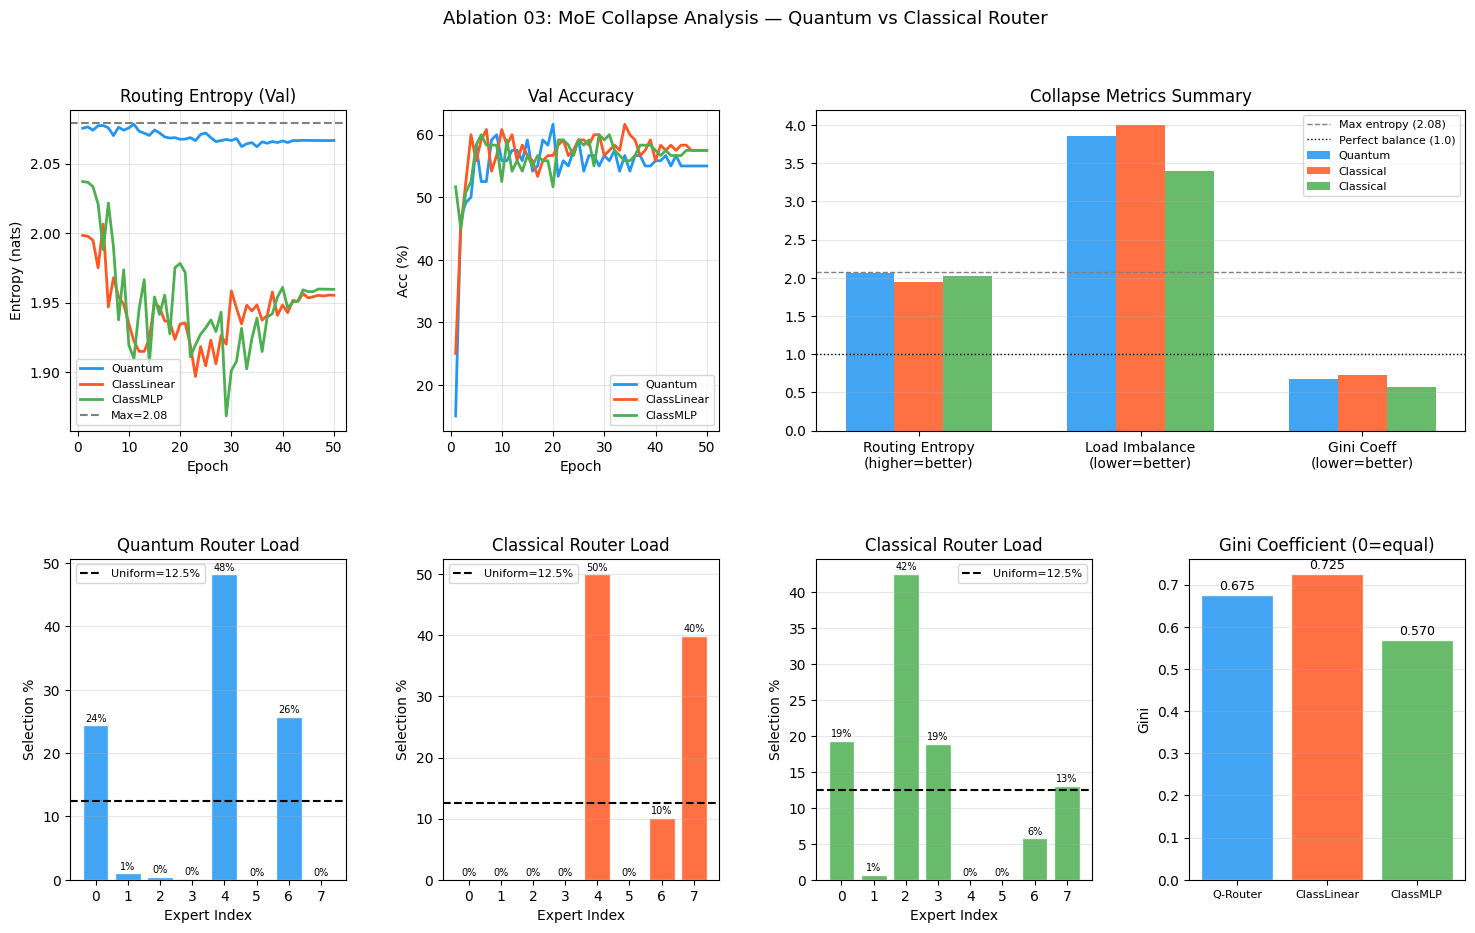

Saved to /content/drive/MyDrive/GQMoE/ablations/03_moe_collapse/ablation03_collapse.png


In [ ]:
names   = list(collapse_results.keys())
colors  = ["#2196F3","#FF5722","#4CAF50"]
n_exp   = config["n_qubits"]

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

# ── Row 0: routing entropy training curves ─────────────────────────────────
ax_ent = fig.add_subplot(gs[0, 0])
for i, (h, label) in enumerate([(hist_q,"Quantum"),(hist_cl,"ClassLinear"),(hist_cm,"ClassMLP")]):
    ep = range(1, len(h["routing_entropy"])+1)
    ax_ent.plot(ep, h["routing_entropy"], label=label, lw=2, color=colors[i])
ax_ent.axhline(max_entropy, ls="--", color="gray", label=f"Max={max_entropy:.2f}")
ax_ent.set_title("Routing Entropy (Val)"); ax_ent.set_xlabel("Epoch")
ax_ent.set_ylabel("Entropy (nats)"); ax_ent.legend(fontsize=8); ax_ent.grid(alpha=0.3)

# ── Row 0: val accuracy ─────────────────────────────────────────────────────
ax_acc = fig.add_subplot(gs[0, 1])
for i, (h, label) in enumerate([(hist_q,"Quantum"),(hist_cl,"ClassLinear"),(hist_cm,"ClassMLP")]):
    ep = range(1, len(h["val_acc"])+1)
    ax_acc.plot(ep, [a*100 for a in h["val_acc"]], label=label, lw=2, color=colors[i])
ax_acc.set_title("Val Accuracy"); ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Acc (%)")
ax_acc.legend(fontsize=8); ax_acc.grid(alpha=0.3)

# ── Row 0: summary bar — entropy, imbalance, gini ──────────────────────────
ax_bar = fig.add_subplot(gs[0, 2:])
metrics    = ["entropy","imbalance","gini"]
m_labels   = ["Routing Entropy\n(higher=better)","Load Imbalance\n(lower=better)","Gini Coeff\n(lower=better)"]
bar_w = 0.22; x = np.arange(len(metrics))
for i, (n, c) in enumerate(zip(names, colors)):
    vals = [collapse_results[n]["entropy"],
            collapse_results[n]["imbalance"],
            collapse_results[n]["gini"]]
    ax_bar.bar(x + i*bar_w - bar_w, vals, width=bar_w, color=c, label=n.split()[0], alpha=0.85)
ax_bar.axhline(max_entropy, ls="--", color="gray", lw=1, label=f"Max entropy ({max_entropy:.2f})")
ax_bar.axhline(1.0, ls=":", color="black", lw=1, label="Perfect balance (1.0)")
ax_bar.set_xticks(x); ax_bar.set_xticklabels(m_labels)
ax_bar.set_title("Collapse Metrics Summary"); ax_bar.legend(fontsize=8); ax_bar.grid(alpha=0.3, axis="y")

# ── Row 1: expert load histograms (one per model) ────────────────────────────
for i, (n, c) in enumerate(zip(names, colors)):
    ax = fig.add_subplot(gs[1, i])
    load = collapse_results[n]["load"]
    bars = ax.bar(range(n_exp), load*100, color=c, alpha=0.85, edgecolor="white")
    ax.axhline(100/n_exp, ls="--", color="black", lw=1.5, label=f"Uniform={100/n_exp:.1f}%")
    ax.set_title(n.split()[0]+" Router Load"); ax.set_xlabel("Expert Index")
    ax.set_ylabel("Selection %"); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
    ax.set_xticks(range(n_exp))
    for j,bar in enumerate(bars):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{load[j]*100:.0f}%", ha="center", va="bottom", fontsize=7)

# Gini comparison
ax_gini = fig.add_subplot(gs[1, 3])
ginis = [collapse_results[n]["gini"] for n in names]
bars  = ax_gini.bar(range(len(names)), ginis, color=colors, alpha=0.85, edgecolor="white")
ax_gini.set_xticks(range(len(names))); ax_gini.set_xticklabels(["Q-Router","ClassLinear","ClassMLP"], fontsize=8)
ax_gini.set_title("Gini Coefficient (0=equal)"); ax_gini.set_ylabel("Gini"); ax_gini.grid(alpha=0.3,axis="y")
for bar,g in zip(bars,ginis): ax_gini.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f"{g:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Ablation 03: MoE Collapse Analysis — Quantum vs Classical Router", fontsize=13)
plt.savefig(f"{ABLATION_DIR}/ablation03_collapse.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {ABLATION_DIR}/ablation03_collapse.png")
